# Standalone Population Density to GeoZarr Notebook

This notebook contains the complete flow in one file. It does not call any external project script.

It does the following:

1. Looks up the Swiss BFS STATPOP geodata ZIP asset
2. Downloads or reuses the ZIP
3. Finds the correct CSV inside the ZIP
4. Reads LV95 grid coordinates and population counts
5. Computes population density per km²
6. Writes an xarray/Zarr store that can be used as GeoZarr-style raster data
7. Opens and visualizes the result

The output grid uses Swiss LV95 coordinates, `EPSG:2056`, with 100 m cells.

## 0. Optional Install

Run this if your environment is missing dependencies. `certifi` helps with local Python SSL certificate issues.

In [ ]:
# Uncomment if needed:
# %pip install requests certifi pandas numpy xarray zarr matplotlib


## 1. Configuration

Set `RUN_CONVERSION = True` when you want to download and convert the data.

If you get a certificate error, first try installing `certifi`. If that still fails in a local/dev environment, set `USE_INSECURE_TLS = True`.

In [1]:
from pathlib import Path
import importlib.util

YEAR = 2024
PROJECT_ROOT = Path.cwd()
CACHE_DIR = PROJECT_ROOT / "data"
ZIP_PATH = CACHE_DIR / f"statpop_geodata_{YEAR}.zip"
ZARR_PATH = CACHE_DIR / f"population_density_{YEAR}.zarr"

RUN_CONVERSION = True
FORCE_DOWNLOAD = False
FORCE_OVERWRITE_ZARR = False
USE_INSECURE_TLS = True
CA_BUNDLE = None  # Example: "/path/to/company-ca-bundle.pem"

print("Project root:", PROJECT_ROOT)
print("ZIP cache:", ZIP_PATH)
print("Zarr output:", ZARR_PATH)


Project root: /Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines
ZIP cache: /Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines/data/statpop_geodata_2024.zip
Zarr output: /Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines/data/population_density_2024.zarr


## 2. Dependency Check

In [2]:
required = ["requests", "pandas", "numpy", "xarray", "zarr"]
optional = ["matplotlib", "certifi"]

missing_required = [name for name in required if importlib.util.find_spec(name) is None]
missing_optional = [name for name in optional if importlib.util.find_spec(name) is None]

print("Missing required:", missing_required or "none")
print("Missing optional:", missing_optional or "none")

if missing_required:
    print("Install with:")
    print("%pip install " + " ".join(missing_required))


Missing required: none
Missing optional: none


## 3. Full Inline Implementation

Everything below is the standalone implementation. No external local script is imported.

In [3]:
import csv
import re
import shutil
import zipfile
from urllib.parse import urlencode

import requests

BFS_ASSETS_URL = "https://dam-api.bfs.admin.ch/hub/api/dam/assets"
STATPOP_QUERY = "%Geodaten STATPOP%"
CELL_SIZE_M = 100
CELL_AREA_KM2 = (CELL_SIZE_M * CELL_SIZE_M) / 1_000_000


def log(message):
    print(message, flush=True)


def default_verify():
    if USE_INSECURE_TLS:
        return False
    if CA_BUNDLE:
        return CA_BUNDLE
    try:
        import certifi
    except ImportError:
        return True
    return certifi.where()


def request_json(url, verify=True):
    response = requests.get(url, headers={"Accept": "application/json"}, timeout=60, verify=verify)
    response.raise_for_status()
    return response.json()


def download(url, path, verify=True):
    path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=120, verify=verify) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length") or 0)
        written = 0
        last_reported = 0
        with path.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)
                    written += len(chunk)
                    if total and written - last_reported >= 25 * 1024 * 1024:
                        log(f"Downloaded {written / 1024 / 1024:.0f} MiB / {total / 1024 / 1024:.0f} MiB")
                        last_reported = written
        log(f"Downloaded {written / 1024 / 1024:.1f} MiB to {path}")
    return path


def latest_statpop_asset(year=None, verify=True):
    query = urlencode({"extendedSearch": STATPOP_QUERY, "limit": 100, "orderBy": "LAST_UPDATED"})
    data = request_json(f"{BFS_ASSETS_URL}?{query}", verify=verify)
    assets = [
        asset
        for asset in data.get("data", [])
        if asset.get("shop", {}).get("orderNr", "").startswith("ag-b-00.03-vz")
        and any(link.get("rel") == "master" and link.get("format") == "zip" for link in asset.get("links", []))
    ]
    if year is not None:
        assets = [asset for asset in assets if asset.get("description", {}).get("bibliography", {}).get("period") == str(year)]
    if not assets:
        raise RuntimeError(f"No STATPOP geodata ZIP found for year={year!r}")
    return max(assets, key=lambda asset: int(asset["description"]["bibliography"]["period"]))


def master_link(asset):
    for link in asset.get("links", []):
        if link.get("rel") == "master" and link.get("format") == "zip":
            return link["href"]
    raise RuntimeError("Selected STATPOP asset has no ZIP master link")


def csv_members(zip_path):
    with zipfile.ZipFile(zip_path) as zip_file:
        return [name for name in zip_file.namelist() if name.lower().endswith(".csv")]


def sniff_delimiter(zip_path, member):
    with zipfile.ZipFile(zip_path) as zip_file, zip_file.open(member) as file:
        sample = file.read(8192).decode("utf-8-sig", errors="replace")
    return csv.Sniffer().sniff(sample, delimiters=";,|\t,").delimiter


def header(zip_path, member):
    import pandas as pd

    delimiter = sniff_delimiter(zip_path, member)
    with zipfile.ZipFile(zip_path) as zip_file, zip_file.open(member) as file:
        return pd.read_csv(file, sep=delimiter, nrows=0).columns.tolist()


def find_coordinate_columns(columns, required=True):
    candidates = [("E_KOORD", "N_KOORD"), ("E_Koord", "N_Koord"), ("E", "N"), ("X", "Y"), ("x", "y")]
    normalized = {column.lower(): column for column in columns}
    for east, north in candidates:
        if east.lower() in normalized and north.lower() in normalized:
            return normalized[east.lower()], normalized[north.lower()]
    if required:
        raise RuntimeError(f"Could not find LV95 coordinate columns in: {columns[:30]}")
    return None


def find_population_column(columns, year):
    preferred = ["BBTOT", f"B{str(year)[-2:]}BTOT"]
    normalized = {column.upper(): column for column in columns}
    for candidate in preferred:
        if candidate in normalized:
            return normalized[candidate]
    fallback = [column for column in columns if re.match(r"^B\d{2}BTOT$", column, re.IGNORECASE)]
    if fallback:
        return sorted(fallback)[-1]
    raise RuntimeError(f"Could not find a STATPOP total-population column like BBTOT or {preferred[-1]}")


def choose_csv(zip_path, year):
    members = csv_members(zip_path)
    if not members:
        raise RuntimeError(f"No CSV files found inside {zip_path}")

    scored = []
    total_col_pattern = re.compile(rf"^(BBTOT|B{str(year)[-2:]}BTOT)$", re.IGNORECASE)
    for member in members:
        columns = header(zip_path, member)
        score = 0
        if find_coordinate_columns(columns, required=False):
            score += 10
        if any(total_col_pattern.match(column) for column in columns):
            score += 10
        if "statpop" in member.lower():
            score += 2
        scored.append((score, member, columns))

    score, member, columns = max(scored, key=lambda item: item[0])
    if score < 20:
        raise RuntimeError(f"Could not confidently identify the STATPOP hectare CSV. Best candidate was {member} with columns: {columns[:20]}")
    return member, columns


In [4]:
def read_density_table(zip_path, member, columns, year):
    import pandas as pd

    east_col, north_col = find_coordinate_columns(columns)
    population_col = find_population_column(columns, year)
    delimiter = sniff_delimiter(zip_path, member)
    log(f"Using columns x={east_col}, y={north_col}, population={population_col}")

    with zipfile.ZipFile(zip_path) as zip_file, zip_file.open(member) as file:
        df = pd.read_csv(file, sep=delimiter, usecols=[east_col, north_col, population_col])

    df = df.rename(columns={east_col: "x", north_col: "y", population_col: "population"})
    df["x"] = pd.to_numeric(df["x"], errors="raise").astype("int64")
    df["y"] = pd.to_numeric(df["y"], errors="raise").astype("int64")
    df["population"] = pd.to_numeric(df["population"], errors="coerce").fillna(0).astype("float32")
    df["population_density_per_km2"] = (df["population"] / CELL_AREA_KM2).astype("float32")
    return df


def density_to_dataset(df, year):
    import numpy as np
    import xarray as xr

    x = np.arange(df["x"].min(), df["x"].max() + CELL_SIZE_M, CELL_SIZE_M, dtype="int64")
    y = np.arange(df["y"].min(), df["y"].max() + CELL_SIZE_M, CELL_SIZE_M, dtype="int64")
    log(f"Building grid: {len(x)} columns x {len(y)} rows from {len(df)} occupied cells")

    xi = ((df["x"].to_numpy() - x[0]) // CELL_SIZE_M).astype("int64")
    yi = ((df["y"].to_numpy() - y[0]) // CELL_SIZE_M).astype("int64")

    density = np.full((len(y), len(x)), np.nan, dtype="float32")
    population = np.full((len(y), len(x)), np.nan, dtype="float32")
    density[yi, xi] = df["population_density_per_km2"].to_numpy(dtype="float32")
    population[yi, xi] = df["population"].to_numpy(dtype="float32")

    ds = xr.Dataset(
        data_vars={
            "population_density_per_km2": (("y", "x"), density),
            "population": (("y", "x"), population),
        },
        coords={"x": x, "y": y},
        attrs={
            "title": f"BFS STATPOP population density {year}",
            "source": "Swiss Federal Statistical Office STATPOP geodata",
            "crs": "EPSG:2056",
            "cell_size_m": CELL_SIZE_M,
            "cell_area_km2": CELL_AREA_KM2,
        },
    )
    ds["spatial_ref"] = xr.DataArray(
        0,
        attrs={
            "grid_mapping_name": "transverse_mercator",
            "epsg_code": "EPSG:2056",
            "crs_wkt": "EPSG:2056",
        },
    )
    for variable in ("population_density_per_km2", "population"):
        ds[variable].attrs["grid_mapping"] = "spatial_ref"
    return ds


def write_zarr(ds, out_path, chunk_size=1024, force=False):
    if out_path.exists():
        if not force:
            raise RuntimeError(f"Output already exists: {out_path}. Set FORCE_OVERWRITE_ZARR = True to overwrite.")
        log(f"Removing existing output: {out_path}")
        shutil.rmtree(out_path)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    encoding = {}
    for variable in ds.data_vars:
        if {"y", "x"}.issubset(ds[variable].dims):
            encoding[variable] = {"chunks": (min(chunk_size, ds.sizes["y"]), min(chunk_size, ds.sizes["x"]))}

    log(f"Writing GeoZarr/Zarr store: {out_path}")
    ds.to_zarr(out_path, mode="w", consolidated=True, encoding=encoding)
    log(f"Wrote {out_path}")
    return out_path


## 4. Dry Run: Resolve the Source Asset

This does not download the ZIP. It only checks which source asset will be used.

In [5]:
verify = default_verify()
try:
    asset = latest_statpop_asset(YEAR, verify=verify)
    source_url = master_link(asset)
    selected_year = int(asset["description"]["bibliography"]["period"])
    print(f"Selected STATPOP {selected_year}")
    print("DAM id:", asset["ids"]["damId"])
    print("Order number:", asset["shop"]["orderNr"])
    print("Source URL:", source_url)
except requests.exceptions.SSLError as exc:
    print("TLS certificate verification failed in this Python environment.")
    print("First try: %pip install certifi")
    print("If this is only local development, set USE_INSECURE_TLS = True in the config cell and rerun.")
    raise


/Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/.venv/lib/python3.14/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'dam-api.bfs.admin.ch'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Selected STATPOP 2024
DAM id: 36171301
Order number: ag-b-00.03-vz2024statpop
Source URL: https://dam-api.bfs.admin.ch/hub/api/dam/assets/36171301/master


## 5. Download and Convert

Set `RUN_CONVERSION = True` in the configuration cell to run this section.

In [6]:
if RUN_CONVERSION:
    if FORCE_DOWNLOAD and ZIP_PATH.exists():
        ZIP_PATH.unlink()

    if ZIP_PATH.exists():
        log(f"Using cached ZIP: {ZIP_PATH}")
    else:
        log(f"Downloading STATPOP {selected_year} to {ZIP_PATH}")
        download(source_url, ZIP_PATH, verify=verify)

    member, columns = choose_csv(ZIP_PATH, selected_year)
    log(f"Reading {member}")
    density_df = read_density_table(ZIP_PATH, member, columns, selected_year)
    density_ds = density_to_dataset(density_df, selected_year)
    write_zarr(density_ds, ZARR_PATH, chunk_size=1024, force=FORCE_OVERWRITE_ZARR)
else:
    print("RUN_CONVERSION is False. Set it to True in the configuration cell to download and convert.")
    print("Expected output:", ZARR_PATH)


Using cached ZIP: /Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines/data/statpop_geodata_2024.zip
Reading STATPOP2024.csv
Using columns x=E_KOORD, y=N_KOORD, population=BBTOT
Building grid: 3459 columns x 2194 rows from 347736 occupied cells
Writing GeoZarr/Zarr store: /Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines/data/population_density_2024.zarr
Wrote /Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines/data/population_density_2024.zarr


/Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 6. Open the Zarr Store

In [11]:
if not ZARR_PATH.exists():
    raise FileNotFoundError(f"Zarr store not found: {ZARR_PATH}. Run the conversion cell first.")

import xarray as xr

ds = xr.open_zarr(ZARR_PATH, consolidated=True)
ds
ZARR_PATH

PosixPath('/Users/justin.ceronio/python/bit-hackathon-gruppe-21-Siedlungsqualitaet-im-Profil/data-pipelines/data/population_density_2024.zarr')

## 7. Summary Statistics

In [8]:
density = ds["population_density_per_km2"]
population = ds["population"]

summary = {
    "grid_shape": tuple(density.shape),
    "x_range": (float(ds.x.min()), float(ds.x.max())),
    "y_range": (float(ds.y.min()), float(ds.y.max())),
    "occupied_cells": int(population.notnull().sum()),
    "population_total": float(population.sum(skipna=True)),
    "density_min": float(density.min(skipna=True)),
    "density_mean": float(density.mean(skipna=True)),
    "density_max": float(density.max(skipna=True)),
}

summary


{'grid_shape': (2194, 3459),
 'x_range': (2486200.0, 2832000.0),
 'y_range': (1075500.0, 1294800.0),
 'occupied_cells': 347736,
 'population_total': 9123704.0,
 'density_min': 300.0,
 'density_mean': 2623.74462890625,
 'density_max': 409000.0}

## 8. Plot the Density Raster

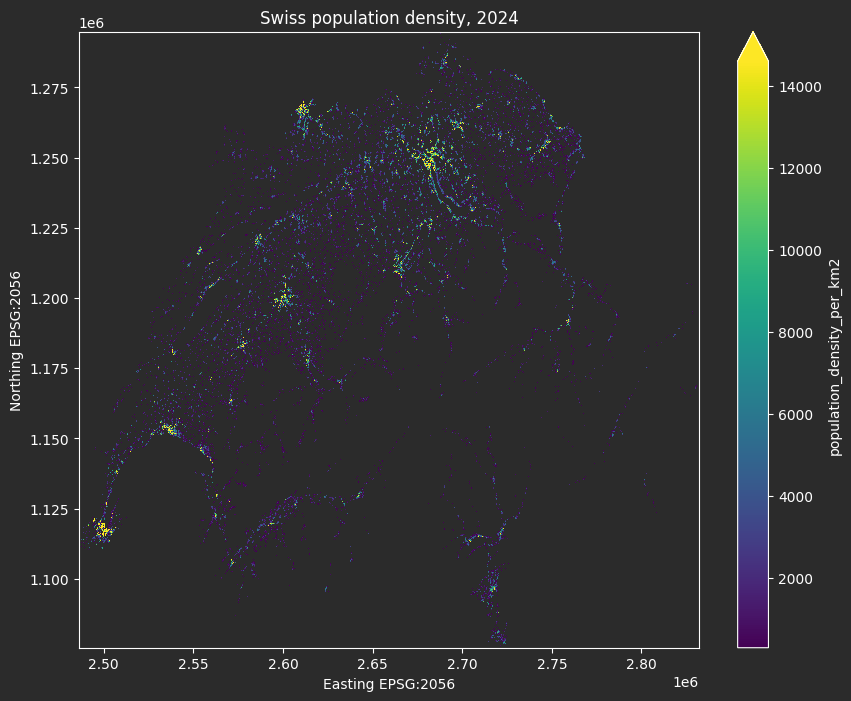

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
density.plot(robust=True, cmap="viridis")
plt.title(f"Swiss population density, {YEAR}")
plt.xlabel("Easting EPSG:2056")
plt.ylabel("Northing EPSG:2056")
plt.show()


## 9. Query Example Locations

Coordinates are approximate city-center LV95 coordinates.

In [10]:
locations = {
    "Zurich": (2683000, 1248000),
    "Bern": (2600000, 1200000),
    "Lausanne": (2538000, 1152000),
    "Basel": (2611000, 1267000),
}

for name, (x, y) in locations.items():
    point = ds.sel(x=x, y=y, method="nearest")
    print(name)
    print("  nearest x/y:", float(point.x), float(point.y))
    print("  population:", float(point.population.values))
    print("  density/km2:", float(point.population_density_per_km2.values))


Zurich
  nearest x/y: 2683000.0 1248000.0
  population: nan
  density/km2: nan
Bern
  nearest x/y: 2600000.0 1200000.0
  population: 4.0
  density/km2: 400.0
Lausanne
  nearest x/y: 2538000.0 1152000.0
  population: nan
  density/km2: nan
Basel
  nearest x/y: 2611000.0 1267000.0
  population: 68.0
  density/km2: 6800.0


## 10. Save a Preview PNG

In [ ]:
preview_path = CACHE_DIR / f"population_density_{YEAR}_preview.png"
preview_path.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
density.plot(robust=True, cmap="viridis")
plt.title(f"Swiss population density, {YEAR}")
plt.xlabel("Easting EPSG:2056")
plt.ylabel("Northing EPSG:2056")
plt.tight_layout()
plt.savefig(preview_path, dpi=160)
plt.close()

preview_path
